In [1]:
from simulator import Config, Simulator

config = Config()
config.NODE_POWER_W = 0.099 # Node power consumption in W
simulator = Simulator(config)

# CSV including time series data for production (G(h) in kWh, and Temperature in °C)
production_data = "raw-data/Colombia.csv"

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from visualization import (
    get_config_trace,
    plot_soc,
    plot_soc_gh,
    plot_soc_ibatt,
    plot_daily,
    plot_seasonal_soc,
    plot_full_soc_analysis,
    plot_pareto_front,
)


## Run Complete Simulation

This single function call executes the entire pipeline:
1. Load irradiance data
2. Compute PV power for all panel sizes
3. Compute hourly power balance with PMU efficiency
4. Simulate battery State of Charge for all configurations
5. Evaluate viability
6. Compute Optimal solutions (Pareto Front)
7. Compute scores of the solutions in Pareto front

In [3]:
# Run the full simulation
results = simulator.run_full_simulation(production_data)

# Extract results
df_pv = results['df_pv']
df_pv_pmu = results['df_pv_pmu']
df_soc = results['df_soc']
summary = results['summary']

Loading irradiance data...
Computing PV power...
Computing hourly balance...
Simulating battery SoC...
Evaluating viability...
Computing optimal scores...
Done!


## Design space

In [4]:
df_design = simulator.build_design_space()
df_design

,panel_area_m2,battery_capacity_Ah,eta_PMU
0,0.000100,0.011,0.70
1,0.000100,0.011,0.75
2,0.000100,0.011,0.80
3,0.000100,0.011,0.85
4,0.000100,0.011,0.87
...,...,...,...
3339,0.061102,3.200,0.85
3340,0.061102,3.200,0.87
3341,0.061102,3.200,0.90
3342,0.061102,3.200,0.95


In [5]:
## Explore Results

In [6]:
print("Top 10 configurations by score:")
summary.head(10)

Top 10 configurations by score:


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
0,0.00625,0.75,0.90,8760,0,1826,0.757745,0.197231,142.666721,305.681591,8760,0,1.50,0.196111,0.0,0.208447,-163.014869,2.240249
1,0.00625,0.88,0.90,8760,0,1826,0.793532,0.168095,142.666721,305.681591,8760,0,1.76,0.196111,0.0,0.208447,-163.014869,2.199484
2,0.00625,0.70,0.95,8760,0,2081,0.768724,0.197030,134.642802,345.718627,8760,0,0.70,0.219918,0.0,0.237557,-211.075825,2.196237
3,0.00800,0.88,0.80,8760,0,1755,0.766965,0.187576,159.032047,319.896359,8760,0,1.76,0.201287,0.0,0.200342,-160.864312,2.187416
4,0.00625,0.75,0.95,8760,0,2081,0.784143,0.183894,134.642802,345.718627,8760,0,1.50,0.219918,0.0,0.237557,-211.075825,2.180558
5,0.00625,1.10,0.87,8760,0,1645,0.819111,0.144404,147.940016,282.836535,8760,0,2.00,0.182478,0.0,0.187785,-134.896518,2.172866
6,0.00800,0.70,0.85,8760,0,2073,0.743220,0.218089,149.052662,366.374819,8760,0,0.70,0.228656,0.0,0.236644,-217.322157,2.169422
7,0.00625,0.70,0.98,8760,0,2199,0.781693,0.190316,130.229316,370.913264,8760,0,0.70,0.234855,0.0,0.251027,-240.683949,2.168615
8,0.00800,0.75,0.85,8760,0,2073,0.760338,0.203550,149.052662,366.374819,8760,0,1.50,0.228656,0.0,0.236644,-217.322157,2.153743
9,0.00625,0.75,0.98,8760,0,2199,0.796247,0.177628,130.229316,370.913264,8760,0,1.50,0.234855,0.0,0.251027,-240.683949,2.152936


## Best combinations

In [7]:
print(summary["score"].max())
best_configs = summary[summary["score"] == summary["score"].max()]

print(len(best_configs))

for config_idx, config_row in best_configs.iterrows():
    print()
    print(config_row[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

2.240249172871311
1

panel_area_m2    0.006250
C_batt_Ah        0.750000
eta_PMU          0.900000
score            2.240249
Name: 0, dtype: float64


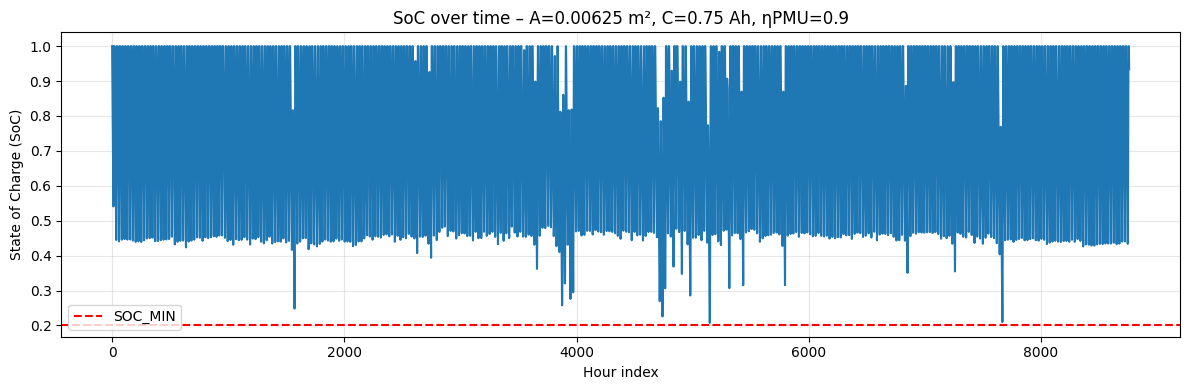

In [8]:
for _, cfg in best_configs.iterrows():
    config_soc = df_soc[
        (df_soc['panel_area_m2'] == cfg['panel_area_m2']) &
        (df_soc['C_batt_Ah'] == cfg['C_batt_Ah']) &
        (df_soc['eta_PMU'] == cfg['eta_PMU'])
    ].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(config_soc['hour_index'], config_soc['SoC'])
    plt.axhline(y=Config.SOC_MIN, color='r', linestyle='--', label='SOC_MIN')
    plt.xlabel('Hour index')
    plt.ylabel('State of Charge (SoC)')
    plt.title(
        f"SoC over time – A={cfg['panel_area_m2']} m², "
        f"C={cfg['C_batt_Ah']} Ah, ηPMU={cfg['eta_PMU']}"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Plot best configurations

Visualize all configurations in 3D space (panel area × battery capacity × PMU efficiency)

In [9]:
LOG_COLOR = False

data = summary.copy()

if LOG_COLOR:
    eps = 1e-9
    data["score_color"] = np.log10(data["score"] + eps)
    color_label = "log10(score)"
else:
    data["score_color"] = data["score"]
    color_label = "score"

fig = px.scatter_3d(
    data,
    x="panel_area_m2",
    y="C_batt_Ah",
    z="eta_PMU",
    color="score_color",
    labels={
        "panel_area_m2": "Panel area (m²)",
        "C_batt_Ah": "Battery (Ah)",
        "eta_PMU": "PMU efficiency",
        "score_color": color_label
    },
    opacity=0.85
)

fig.update_layout(
    width=1000,
    height=800,
    title=f"All configurations ({'log color scale' if LOG_COLOR else 'linear color scale'})"
)

fig.show()

## Score Distribution Histogram

In [10]:
summary_plot = summary[summary["score"] > 0].copy()

fig = px.histogram(
    summary_plot,
    x="score",
    nbins=50,
    labels={"score": "score"},
    opacity=0.85,
)

fig.update_layout(
    width=900,
    height=500,
    title="Score distribution (score > 0)",
    bargap=0.05
)

fig.show()

## Score at Maximum PMU Efficiency (not best configs)

In [11]:
eta_max = summary["eta_PMU"].max()
df_plane = summary[summary["eta_PMU"] == eta_max].copy()

df_pivot = (
    df_plane
    .pivot_table(
        index="C_batt_Ah",
        columns="panel_area_m2",
        values="score",
        aggfunc="mean"
    )
    .sort_index()
    .sort_index(axis=1)
)

X = df_pivot.columns.values
Y = df_pivot.index.values
X_grid, Y_grid = np.meshgrid(X, Y)
Z = df_pivot.values

fig = go.Figure(
    data=[
        go.Surface(
            x=X_grid,
            y=Y_grid,
            z=Z,
            colorscale="Viridis",
            colorbar={"title": "Score"}
        )
    ]
)

fig.update_layout(
    title=f"Score surface for max η_PMU ({eta_max})",
    scene=dict(
        xaxis_title="Panel area (m²)",
        yaxis_title="Battery capacity (Ah)",
        zaxis_title="Score"
    ),
    width=900,
    height=700
)

fig.show()

## Summary statistics

In [12]:
print("\n=== Simulation Summary ===")
print(f"Total configurations evaluated: {len(summary)}")
print(f"Best score achieved: {summary['score'].max():.4f}")
print(f"Configurations with best score: {len(summary[summary['score'] == summary['score'].max()])}")
print(f"Viable configurations (score > 0): {len(summary[summary['score'] > 0])}")
print(f"Configurations with failures: {len(summary[summary['failure_hours'] > 0])}")
print("Configuration with I_req_max > I_batt_max):",
      len(summary[summary["I_req_max_A"] > summary["I_batt_max_A"]]))



=== Simulation Summary ===
Total configurations evaluated: 3344
Best score achieved: 2.2402
Configurations with best score: 1
Viable configurations (score > 0): 1147
Configurations with failures: 2197
Configuration with I_req_max > I_batt_max): 849


## Invalidad configs due to < SoC_min

In [13]:
invalid_soc = summary[summary["failure_hours"] > 0][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "failure_hours",
    "autonomy_hours",
    "I_batt_max_A",
    "I_req_max_A"
]].sort_values("failure_hours", ascending=False)

invalid_soc


,panel_area_m2,C_batt_Ah,eta_PMU,failure_hours,autonomy_hours,I_batt_max_A,I_req_max_A
3282,0.000100,0.011,0.70,8760,1,0.011,0.038224
1148,0.000100,0.011,0.80,8760,1,0.011,0.033446
1150,0.000100,0.011,0.87,8760,1,0.011,0.030755
1149,0.000100,0.011,0.85,8760,1,0.011,0.031479
2472,0.000625,0.011,0.80,8760,1,0.011,0.033446
...,...,...,...,...,...,...,...
2061,0.016000,0.550,0.85,2,6287,1.000,0.480055
1852,0.010057,0.550,0.87,2,4510,1.000,0.307809
1728,0.010000,1.400,0.70,1,4789,2.000,0.194394
1253,0.004000,2.300,0.95,1,4788,46.000,0.131597


## Invalid configs due I_req > I_batt_max

In [14]:
invalid_peak = summary[
    summary["I_req_max_A"] > summary["I_batt_max_A"]
][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "I_req_max_A",
    "I_batt_max_A",
    "failure_hours",
    "autonomy_hours"
]].sort_values("I_req_max_A", ascending=False)

invalid_peak


,panel_area_m2,C_batt_Ah,eta_PMU,I_req_max_A,I_batt_max_A,failure_hours,autonomy_hours
3211,0.061102,0.011,0.98,2.526146,0.0110,4487,12
3203,0.061102,0.105,0.98,2.526146,0.1575,3740,15
3227,0.061102,0.400,0.98,2.526146,0.6000,470,34
866,0.061102,0.500,0.98,2.526146,0.5000,0,8760
3243,0.061102,0.350,0.98,2.526146,0.5250,1200,21
...,...,...,...,...,...,...,...
2831,0.000400,0.011,0.98,0.027303,0.0110,8760,1
2243,0.001000,0.011,0.98,0.027303,0.0110,7417,8
2477,0.000625,0.011,0.98,0.027303,0.0110,8760,1
3105,0.000250,0.011,0.98,0.027303,0.0110,8760,1


In [15]:
summary["autonomy_hours"].describe()


count    3344.000000
mean     3183.320275
std      4098.363060
min         1.000000
25%        18.000000
50%        51.000000
75%      8760.000000
max      8760.000000
Name: autonomy_hours, dtype: float64

In [16]:
summary.sort_values("autonomy_hours").head(5)


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
2831,0.0004,0.011,0.98,8760,8759,1,0.200091,0.008547,207.483017,-0.0,1,8760,0.011,0.027303,0.999886,0.000114,207.483017,0.0
2830,0.0004,0.011,0.95,8760,8759,1,0.200091,0.008547,215.035837,-0.0,1,8760,0.011,0.028165,0.999886,0.000114,215.035837,0.0
2829,0.0004,0.011,0.90,8760,8759,1,0.200091,0.008547,228.742807,-0.0,1,8760,0.011,0.029730,0.999886,0.000114,228.742807,0.0
2828,0.0004,0.011,0.87,8760,8759,1,0.200091,0.008547,237.723236,-0.0,1,8760,0.011,0.030755,0.999886,0.000114,237.723236,0.0
2827,0.0004,0.011,0.85,8760,8759,1,0.200091,0.008547,244.062362,-0.0,1,8760,0.011,0.031479,0.999886,0.000114,244.062362,0.0


In [17]:
summary.sort_values("autonomy_hours").tail(5)

,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
1140,0.061102,3.20,0.75,8760,0,3686,0.954535,0.050175,159.958002,2637.105610,8760,0,9.6,1.474838,0.0,0.420776,-2477.147608,0.137406
1141,0.061102,3.20,0.80,8760,0,3770,0.958085,0.046918,149.945081,3006.532648,8760,0,9.6,1.679465,0.0,0.430365,-2856.587567,0.117743
1144,0.061102,3.20,0.90,8760,0,3898,0.963657,0.041487,133.262145,3817.998488,8760,0,9.6,2.128582,0.0,0.444977,-3684.736343,0.087781
0,0.006250,0.75,0.90,8760,0,1826,0.757745,0.197231,142.666721,305.681591,8760,0,1.5,0.196111,0.0,0.208447,-163.014869,2.240249
32,0.010057,0.75,0.80,8760,0,2231,0.755238,0.213674,156.607382,422.641467,8760,0,1.5,0.258547,0.0,0.254680,-266.034085,2.083038


In [18]:
# 1) Maximum score configuration
cfg_best = summary.sort_values("score", ascending=False).iloc[0]

# 2) Minimum non-zero score configuration
summary_nonzero = summary[summary["score"] > 0]
cfg_bad = summary_nonzero.sort_values("score", ascending=True).iloc[0]

# 3) Score closest to 0.5 (mid-score representative)
target = 0.5
idx_mid = (summary["score"] - target).abs().idxmin()
cfg_mid = summary.loc[idx_mid]

# 4) Failure case (for comparison)
cfg_fail = summary[summary["score"] == 0].sort_values("score").iloc[0]


print("\n=== BEST SCORE CONFIGURATION ===")
print(cfg_best[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== BAD NON-ZERO SCORE CONFIGURATION ===")
print(cfg_bad[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== MID-SCORE (~0.5) CONFIGURATION ===")
print(cfg_mid[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== FAILURE CASE CONFIGURATION ===")
print(cfg_fail[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])



=== BEST SCORE CONFIGURATION ===
panel_area_m2    0.006250
C_batt_Ah        0.750000
eta_PMU          0.900000
score            2.240249
Name: 0, dtype: float64

=== BAD NON-ZERO SCORE CONFIGURATION ===
panel_area_m2    0.061102
C_batt_Ah        3.200000
eta_PMU          0.980000
score            0.076311
Name: 1146, dtype: float64

=== MID-SCORE (~0.5) CONFIGURATION ===
panel_area_m2    0.056797
C_batt_Ah        2.300000
eta_PMU          0.750000
score            0.499561
Name: 1087, dtype: float64

=== FAILURE CASE CONFIGURATION ===
panel_area_m2    0.0001
C_batt_Ah        0.1050
eta_PMU          0.9000
score            0.0000
Name: 1147, dtype: float64


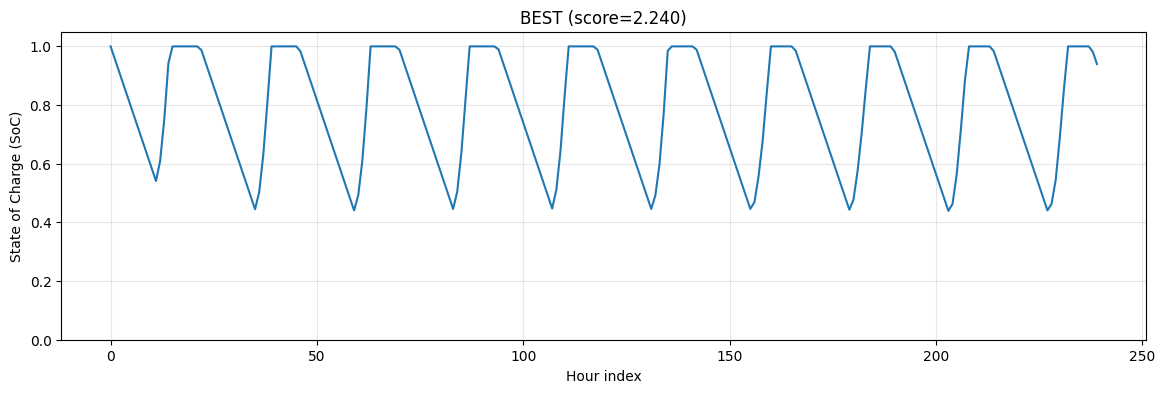

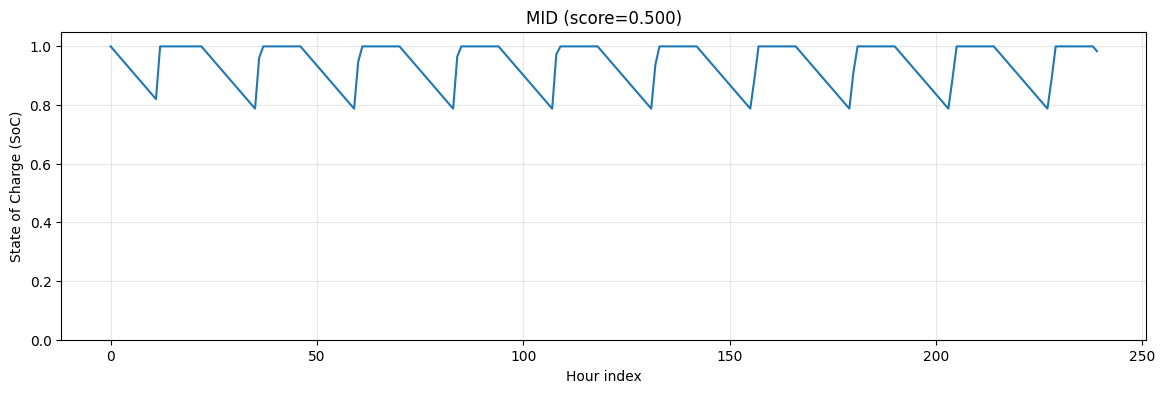

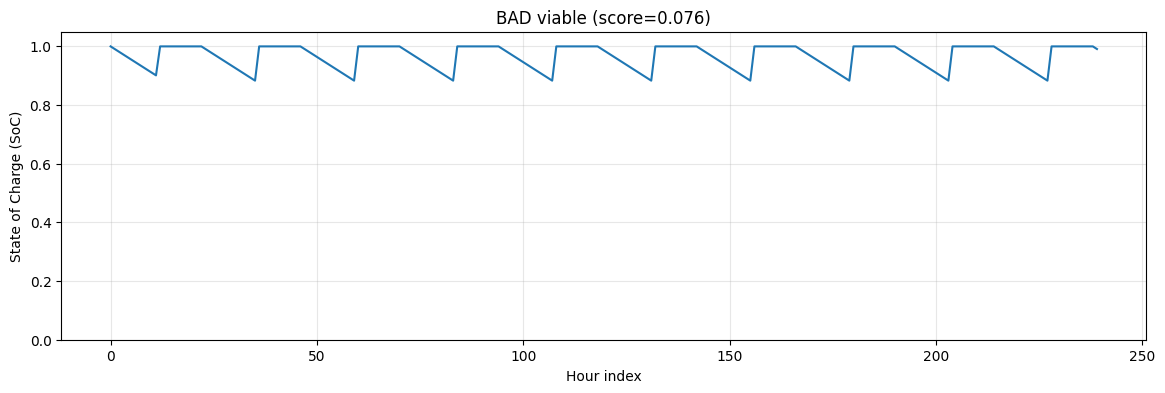

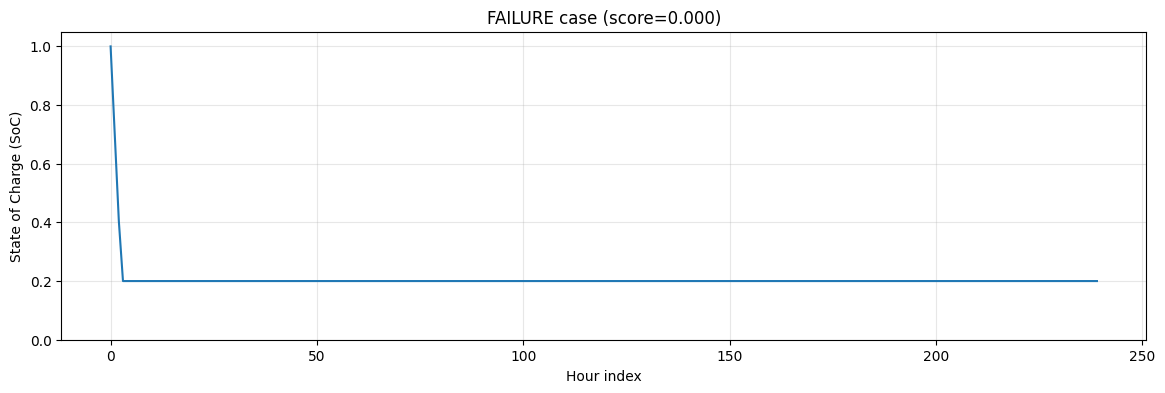

In [19]:
# BEST SCORE
plot_soc(
    df_soc,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    title=f"BEST (score={cfg_best['score']:.3f})"
)

# MID SCORE (~0.5)
plot_soc(
    df_soc,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    title=f"MID (score={cfg_mid['score']:.3f})"
)

# BAD NON-ZERO SCORE
plot_soc(
    df_soc,
    cfg_bad["panel_area_m2"],
    cfg_bad["C_batt_Ah"],
    cfg_bad["eta_PMU"],
    title=f"BAD viable (score={cfg_bad['score']:.3f})"
)

# FAILURE CASE
plot_soc(
    df_soc,
    cfg_fail["panel_area_m2"],
    cfg_fail["C_batt_Ah"],
    cfg_fail["eta_PMU"],
    title=f"FAILURE case (score={cfg_fail['score']:.3f})"
)

In [20]:
from visualization import (
    get_config_trace,
    plot_soc_gh,
    plot_soc_ibatt,
    plot_daily,
    plot_seasonal_soc
)


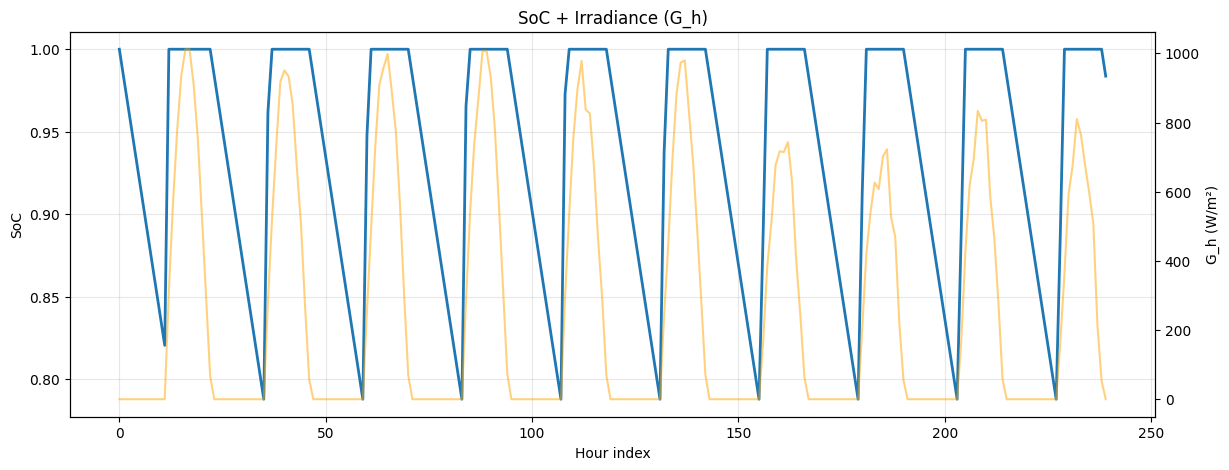

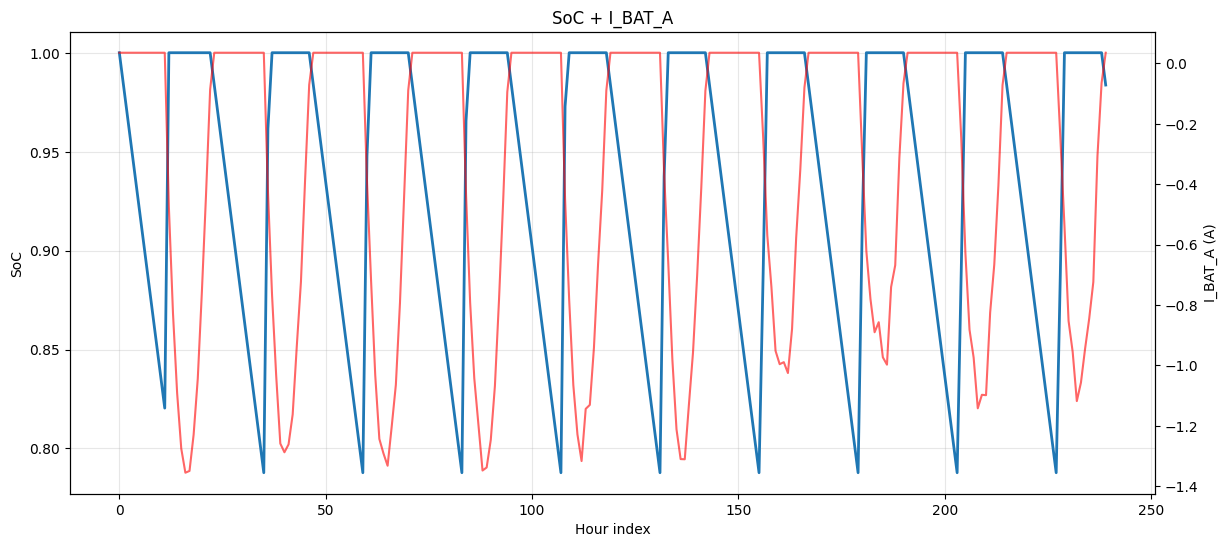

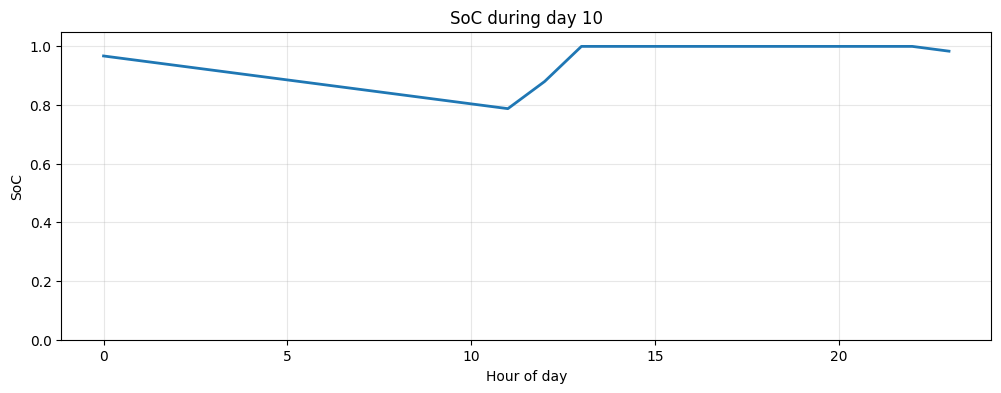

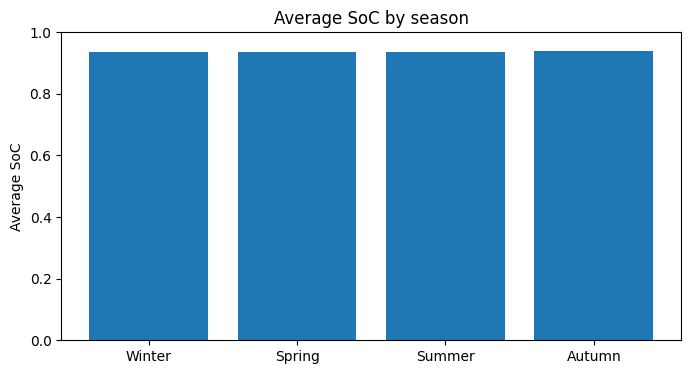

In [21]:
# Choose a configuration, e.g. cfg_mid (score ~0.5)
panel  = cfg_mid["panel_area_m2"]
cap    = cfg_mid["C_batt_Ah"]
eta    = cfg_mid["eta_PMU"]

cfg = get_config_trace(df_soc, panel, cap, eta)

plot_soc_gh(cfg, df_pv, hours=240, title="SoC + Irradiance (G_h)")
plot_soc_ibatt(cfg, hours=240, title="SoC + I_BAT_A")
plot_daily(cfg, day_index=10)
plot_seasonal_soc(cfg)


In [22]:
# Sort all configurations by score
summary_sorted = summary.sort_values("score", ascending=False)

# 1) Best score
cfg_best = summary_sorted.iloc[0]
title_best = f"BEST - Panel: {cfg_best['panel_area_m2']} m², Batería: {cfg_best['C_batt_Ah']} Ah, PMU: {cfg_best['eta_PMU']}, Score: {cfg_best['score']:.3f}"

# 2) BAD non-zero score
cfg_bad = summary_sorted[summary_sorted["score"] > 0].sort_values("score").iloc[0]
title_bad = f"BAD - Panel: {cfg_bad['panel_area_m2']} m², Batería: {cfg_bad['C_batt_Ah']} Ah, PMU: {cfg_bad['eta_PMU']}, Score: {cfg_bad['score']:.3f}"

# 3) MID score (between BAD and BEST)
configs_between = summary_sorted[
    (summary_sorted["score"] > cfg_bad["score"]) &
    (summary_sorted["score"] < cfg_best["score"])
].sort_values("score")
cfg_mid = configs_between.iloc[len(configs_between) // 2]
title_mid = f"MID - Panel: {cfg_mid['panel_area_m2']} m², Batería: {cfg_mid['C_batt_Ah']} Ah, PMU: {cfg_mid['eta_PMU']}, Score: {cfg_mid['score']:.3f}"

# 4) Failure case (for comparison)
cfg_fail = summary_sorted[summary_sorted["score"] == 0].sort_values("score").iloc[0]
title_fail = f"FAIL - Panel: {cfg_fail['panel_area_m2']} m², Batería: {cfg_fail['C_batt_Ah']} Ah, PMU: {cfg_fail['eta_PMU']}, Score: {cfg_fail['score']:.3f}"

print("\nBEST:", cfg_best[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nMID:", cfg_mid[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nBAD:", cfg_bad[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nFAIL:", cfg_fail[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])



BEST: panel_area_m2    0.006250
C_batt_Ah        0.750000
eta_PMU          0.900000
score            2.240249
Name: 0, dtype: float64

MID: panel_area_m2    0.040000
C_batt_Ah        0.550000
eta_PMU          0.950000
score            1.292541
Name: 573, dtype: float64

BAD: panel_area_m2    0.061102
C_batt_Ah        3.200000
eta_PMU          0.980000
score            0.076311
Name: 1146, dtype: float64

FAIL: panel_area_m2    0.0001
C_batt_Ah        0.1050
eta_PMU          0.9000
score            0.0000
Name: 1147, dtype: float64


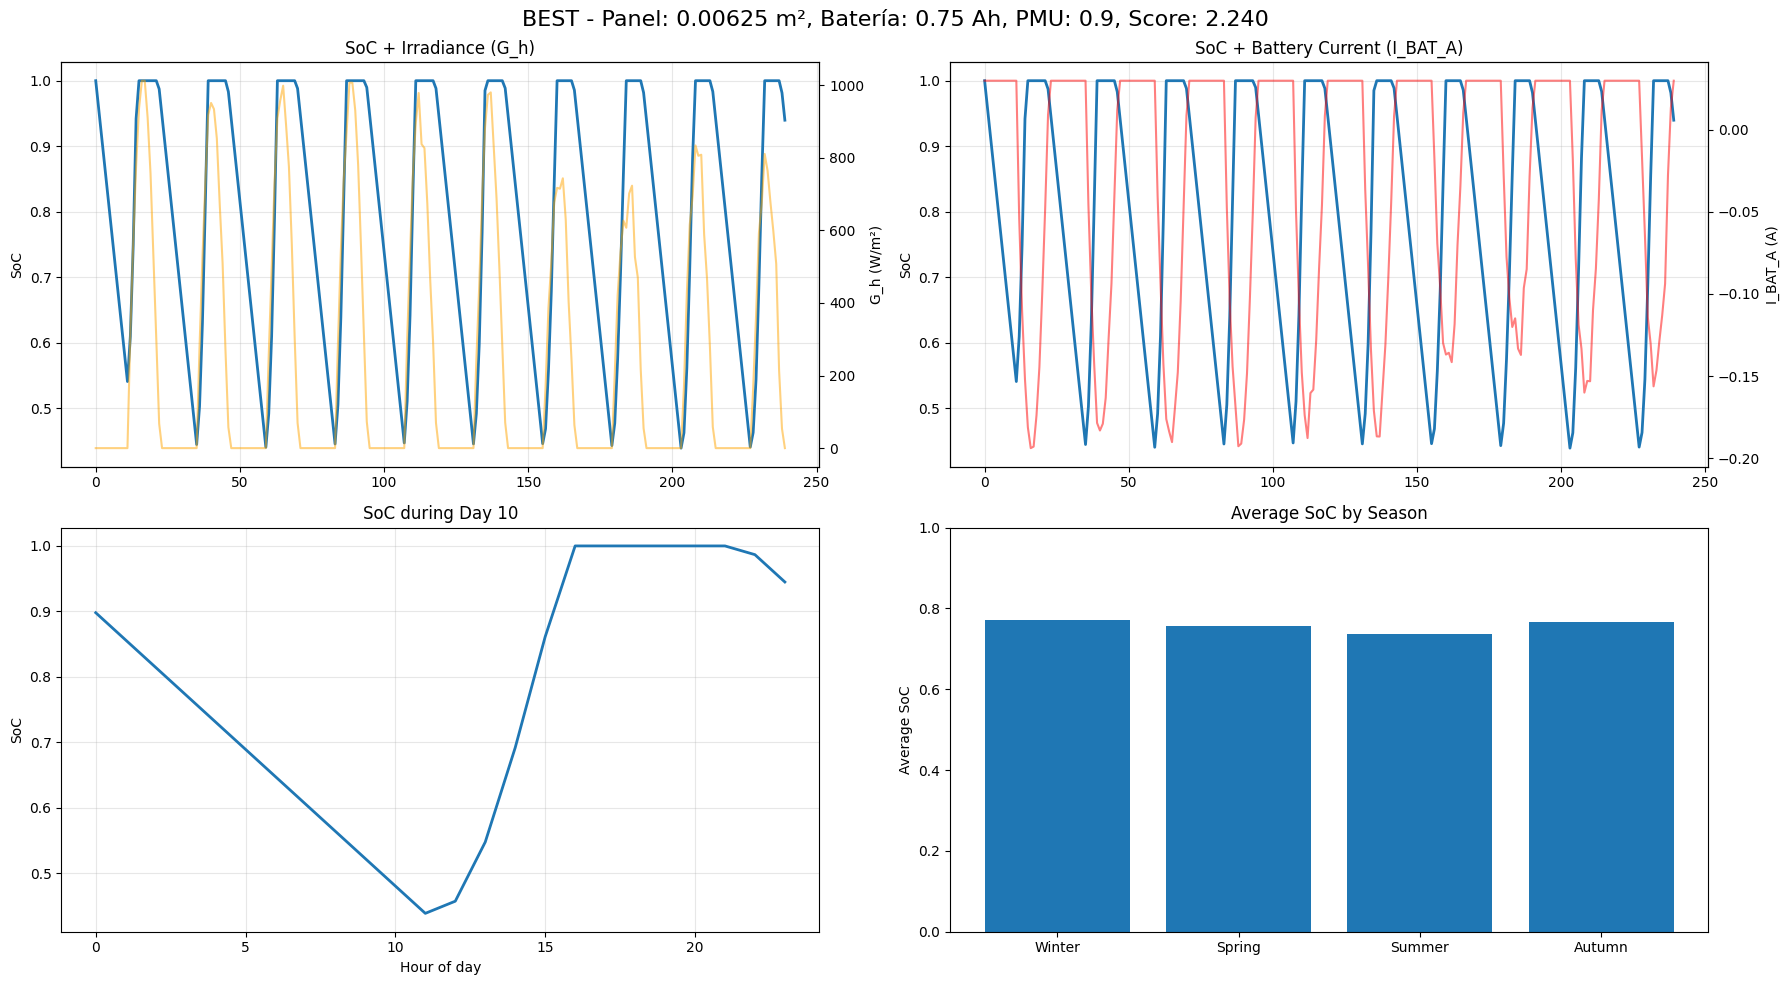

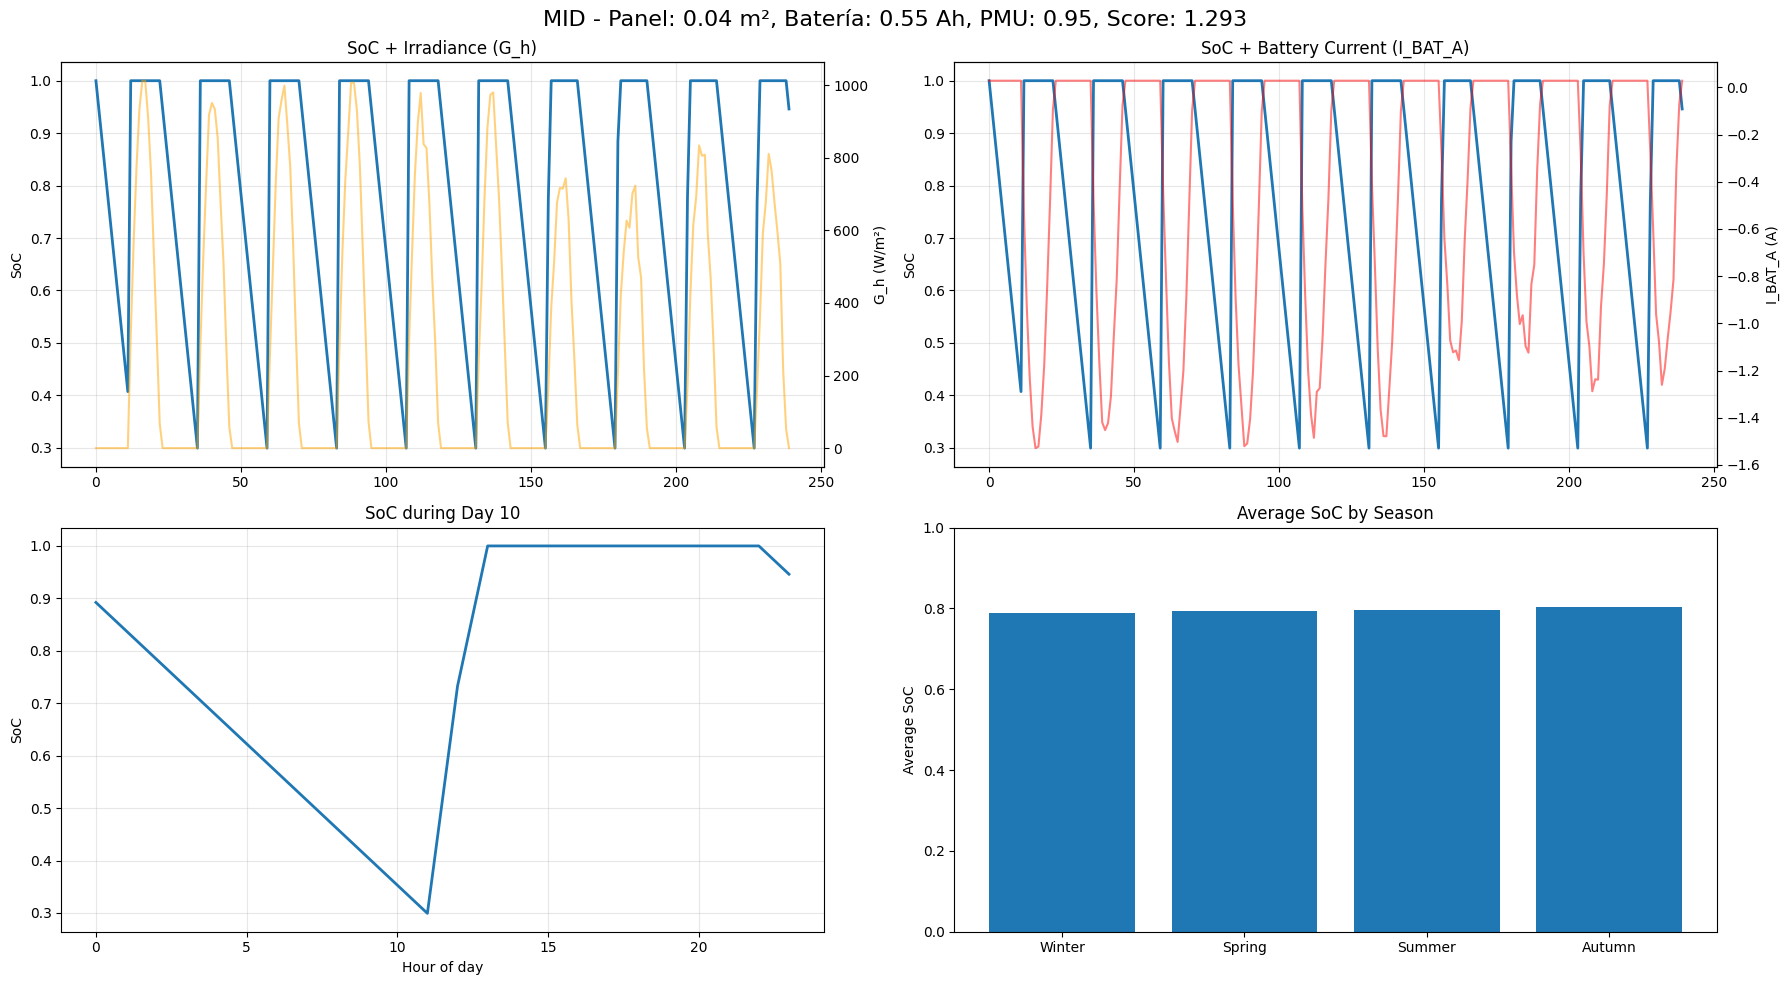

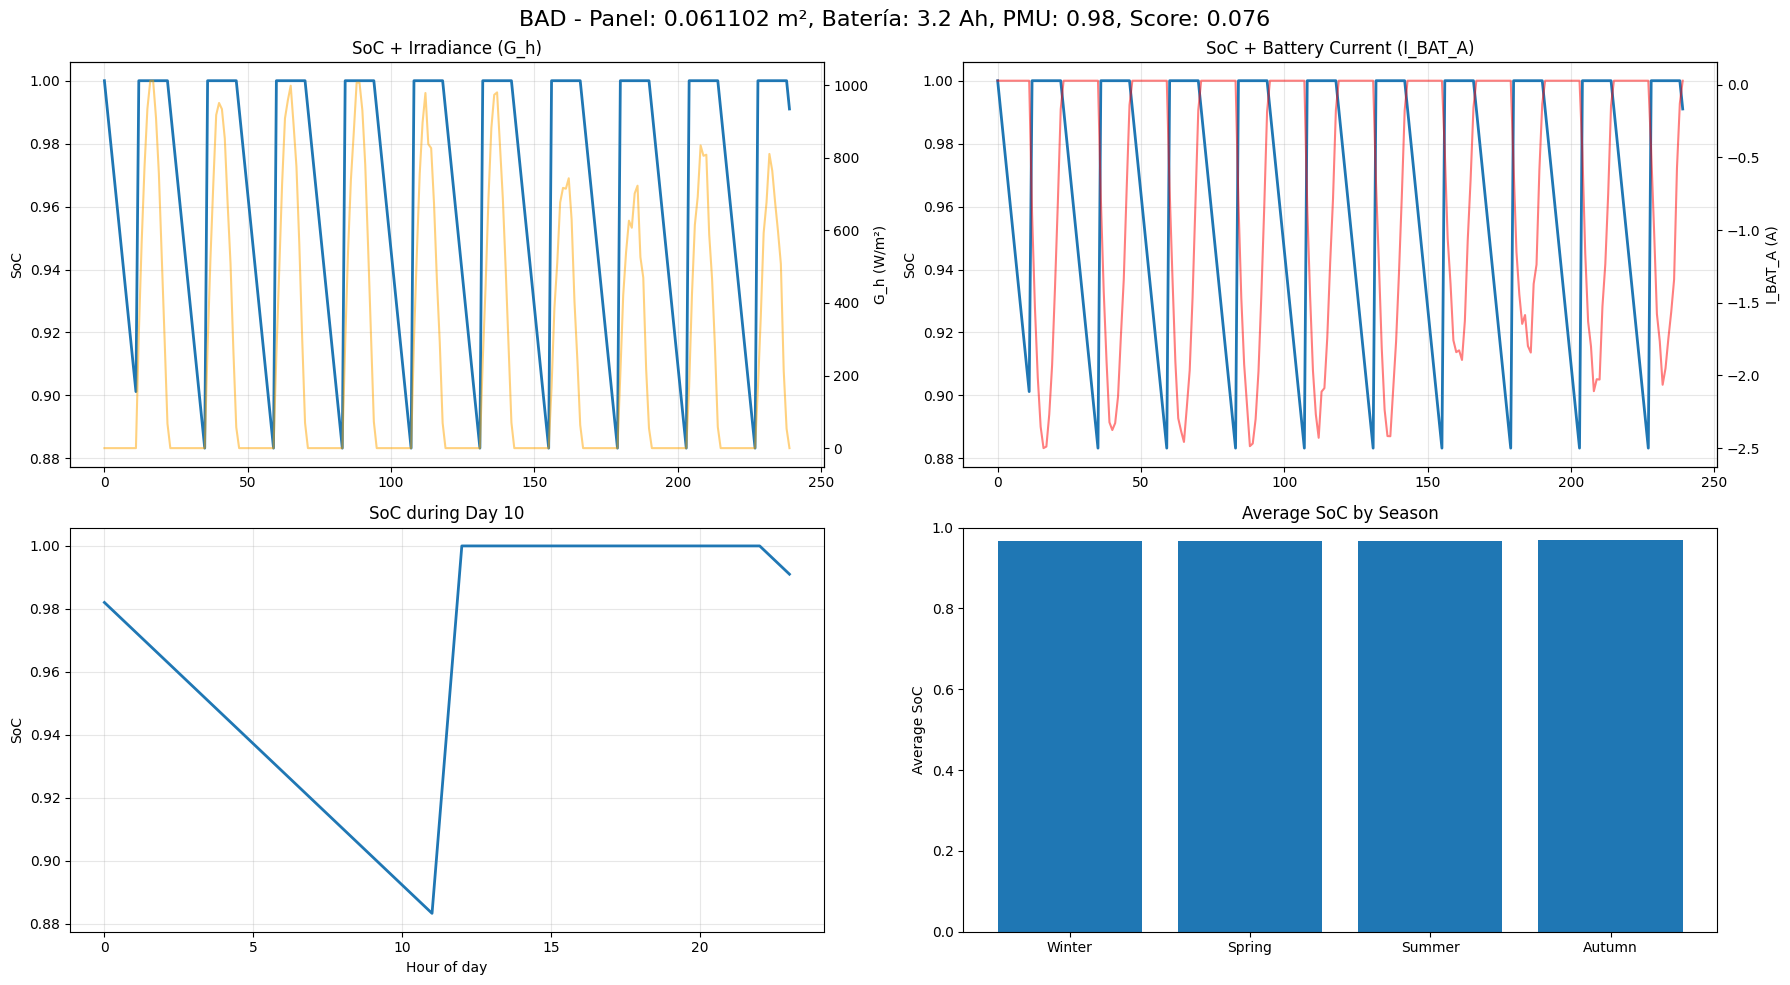

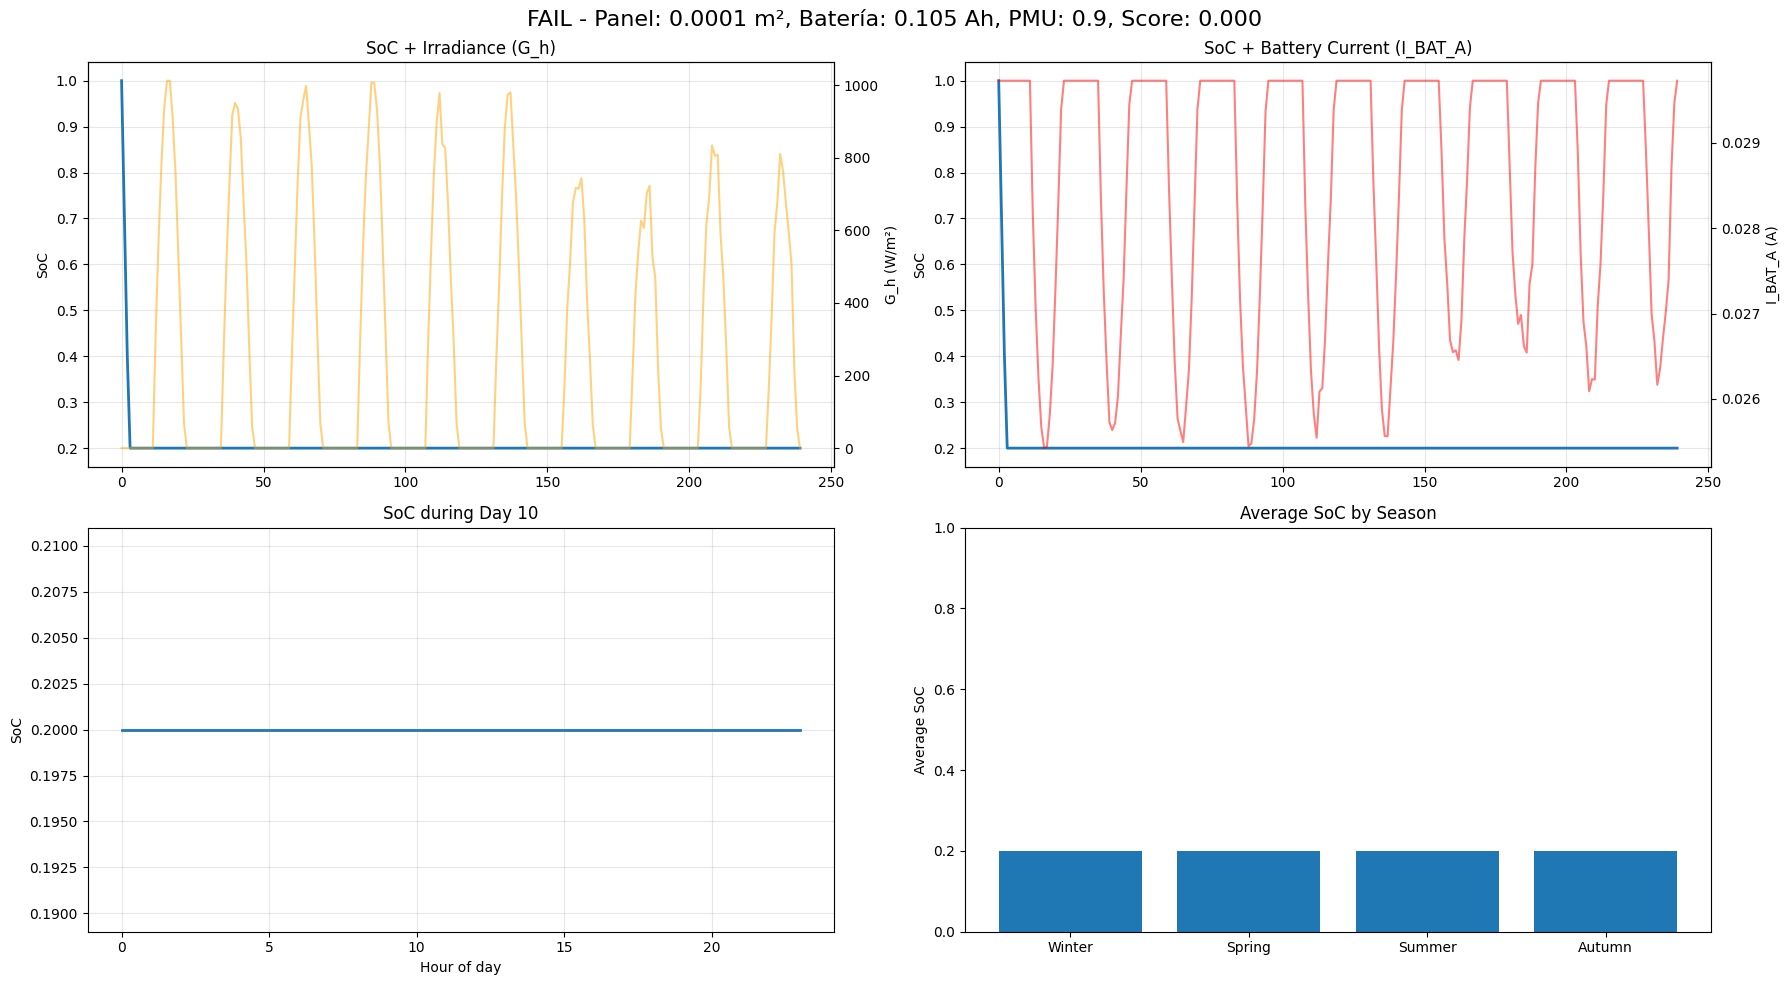

In [23]:
# === BEST SCORE ===
plot_full_soc_analysis(
    title_best,
    df_soc, df_pv,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    hours=240,
    day_index=10
)

# === MID-SCORE (~0.5) ===
plot_full_soc_analysis(
    title_mid,
    df_soc, df_pv,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    hours=240,
    day_index=10
)

# === BAD NON-ZERO SCORE ===
plot_full_soc_analysis(
    title_bad,
    df_soc, df_pv,
    cfg_bad["panel_area_m2"],
    cfg_bad["C_batt_Ah"],
    cfg_bad["eta_PMU"],
    hours=240,
    day_index=10
)

# === FAILURE CASE ===
plot_full_soc_analysis(
    title_fail,
    df_soc, df_pv,
    cfg_fail["panel_area_m2"],
    cfg_fail["C_batt_Ah"],
    cfg_fail["eta_PMU"],
    hours=240,
    day_index=10
)


## Pareto front

In [24]:
# ── Compute Pareto front ────────────────────────────────────────────────────
pareto_objectives = [
    ("C_batt_Ah",        -1),
    ("panel_area_m2",    -1),
    ("soc_full_fraction", -1),
]

front = simulator.pareto_front(summary, pareto_objectives)

print(f"{len(front)} configurations on the Pareto front (out of "
      f"{(summary['failure_hours'] == 0).sum()} viable ones)\n")

for i, row in front.iterrows():
    print(f"--- Config #{i} ---")
    print(f"  Panel area  : {row['panel_area_m2']*1e4:.1f} cm²  ({row['panel_area_m2']} m²)")
    print(f"  Battery     : {row['C_batt_Ah']} Ah")
    print(f"  η_PMU       : {row['eta_PMU']}")
    print(f"  SoC full    : {row['soc_full_fraction']*100:.1f}%")
    print(f"  Autonomy    : {row['autonomy_hours']} h")
    print(f"  Failures    : {int(row['failure_hours'])} h")
    print()


13 configurations on the Pareto front (out of 1147 viable ones)

--- Config #0 ---
  Panel area  : 80.0 cm²  (0.008 m²)
  Battery     : 0.5 Ah
  η_PMU       : 0.98
  SoC full    : 29.7%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #1 ---
  Panel area  : 80.0 cm²  (0.008 m²)
  Battery     : 0.55 Ah
  η_PMU       : 0.95
  SoC full    : 28.4%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #2 ---
  Panel area  : 62.5 cm²  (0.00625 m²)
  Battery     : 0.7 Ah
  η_PMU       : 0.95
  SoC full    : 23.8%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #3 ---
  Panel area  : 80.0 cm²  (0.008 m²)
  Battery     : 0.7 Ah
  η_PMU       : 0.85
  SoC full    : 23.7%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #4 ---
  Panel area  : 62.5 cm²  (0.00625 m²)
  Battery     : 0.75 Ah
  η_PMU       : 0.9
  SoC full    : 20.8%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #5 ---
  Panel area  : 80.0 cm²  (0.008 m²)
  Battery     : 0.88 Ah
  η_PMU       : 

# Compute score from Pareto front¶
Pareto front¶

In [25]:

score_objectives = [
    ("surplus_Ah",        -0.33),
    ("eta_PMU",           -0.33),
    ("soc_std",           0.34),
]

score = simulator.compute_score(front, score_objectives)

# columnas a mostrar
cols = [
    "panel_area_m2",
    "C_batt_Ah",
    "soc_full_fraction",
    "eta_PMU",
    "soc_mean",
    "soc_std",
    "surplus_Ah",
    "deficit_Ah",
    "hours_soc_full",
    "score",
]

tabla = score[cols]

# función para formatear valores
def fmt(v):
    if isinstance(v, float):
        return f"{v:.5f}"
    return str(v)

# calcular ancho máximo de cada columna
widths = []
for col in tabla.columns:
    max_data = tabla[col].map(fmt).map(len).max()
    widths.append(max(max_data, len(col)))

# encabezado
header = "  ".join(col.ljust(w) for col, w in zip(tabla.columns, widths))
print(header)

# línea separadora
print("-" * len(header))

# filas
for _, row in tabla.iterrows():
    line = "  ".join(fmt(v).ljust(w) for v, w in zip(row, widths))
    print(line)


panel_area_m2  C_batt_Ah  soc_full_fraction  eta_PMU  soc_mean  soc_std  surplus_Ah  deficit_Ah  hours_soc_full  score  
------------------------------------------------------------------------------------------------------------------------
0.00800        0.50000    0.29737            0.98000  0.71763   0.26275  128.05392   501.97590   2605.00000      0.67000
0.00800        0.55000    0.28436            0.95000  0.73039   0.24677  132.36689   468.78912   2491.00000      0.64595
0.00800        0.70000    0.23664            0.85000  0.74322   0.21809  149.05266   366.37482   2073.00000      0.60392
0.00800        0.88000    0.20034            0.80000  0.76696   0.18758  159.03205   319.89636   1755.00000      0.53902
0.00625        0.75000    0.20845            0.90000  0.75774   0.19723  142.66672   305.68159   1826.00000      0.53897
0.00625        0.70000    0.23756            0.95000  0.76872   0.19703  134.64280   345.71863   2081.00000      0.52738
0.00625        1.10000    0.1877

# Visualize SOC through year

Archivo guardado en: Datos_SoC/soc_Soacha.csv
Configuración seleccionada:
panel_area_m2    0.008
C_batt_Ah        0.500
eta_PMU          0.980
score            0.670
Name: 0, dtype: float64


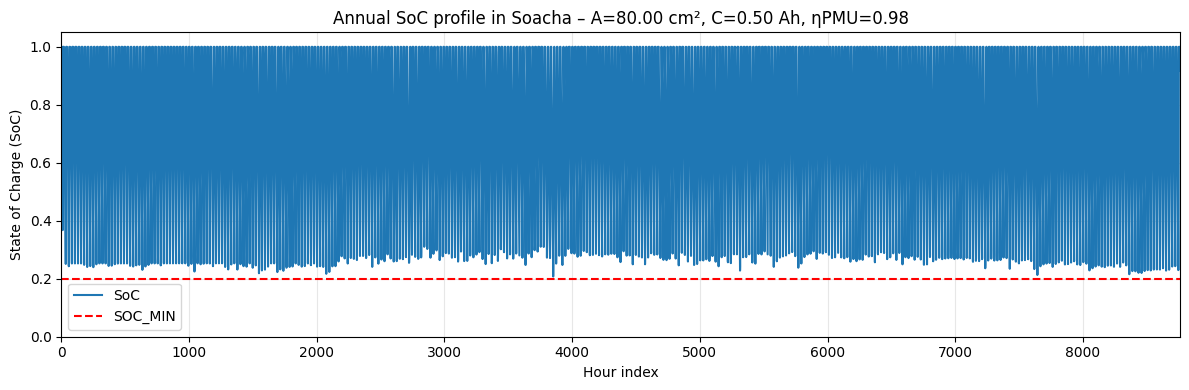

In [26]:
import os

# Elegir la fila de la configuración que querés visualizar
row_idx = 0   # <-- cambiá este valor: 0, 1, 2, ...
ubicacion = "Soacha"  # <-- cambiá este valor: "Ciudad Real", "Almagro", "Valdepeñas", etc.
# Tomar la configuración elegida desde el DataFrame score
cfg = score.iloc[row_idx]

# Filtrar df_soc para obtener la traza SoC de ESA configuración
config_soc = df_soc[
    (df_soc['panel_area_m2'] == cfg['panel_area_m2']) &
    (df_soc['C_batt_Ah'] == cfg['C_batt_Ah']) &
    (df_soc['eta_PMU'] == cfg['eta_PMU'])
].copy()


# Crear carpeta si no existe
output_dir = "Datos_SoC"
os.makedirs(output_dir, exist_ok=True)
filename = f"soc_{ubicacion}.csv"
filepath = os.path.join(output_dir, filename)

# Guardar solo lo necesario
config_soc[['hour_index', 'SoC']].to_csv(filepath, index=False)

print(f"Archivo guardado en: {filepath}")


# Filtrar df_soc para obtener la traza SoC de ESA configuración
config_soc = df_soc[
    (df_soc['panel_area_m2'] == cfg['panel_area_m2']) &
    (df_soc['C_batt_Ah'] == cfg['C_batt_Ah']) &
    (df_soc['eta_PMU'] == cfg['eta_PMU'])
].copy()

# Verificación opcional
print("Configuración seleccionada:")
print(cfg[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

# Gráfico anual del SoC
plt.figure(figsize=(12, 4))
plt.plot(config_soc['hour_index'], config_soc['SoC'], label='SoC')

plt.axhline(y=Config.SOC_MIN, color='r', linestyle='--', label='SOC_MIN')
plt.ylim(0, 1.05)  # Limitar el eje y para mejor visualización
plt.xlim(0, 8760)  # Limitar el eje x a un año (8760 horas)
plt.xlabel('Hour index')
plt.ylabel('State of Charge (SoC)')
plt.title(
    f"Annual SoC profile in {ubicacion} – A={cfg['panel_area_m2']*10000:.2f} cm², "
    f"C={cfg['C_batt_Ah']:.2f} Ah, ηPMU={cfg['eta_PMU']:.2f}"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"Images/soc_plot_{ubicacion}.png", dpi=600, bbox_inches='tight')
plt.show()